In [1]:
import os
import subprocess
import json
import time
import threading
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

from dotenv import load_dotenv
load_dotenv()

from pykrx import stock

DATA_DIR = "hourly_data"
os.makedirs(DATA_DIR, exist_ok=True)

MAX_WORKERS = 3
REFRESH_EVERY_N = 150
REQUEST_DELAY = 0.3

_refresh_lock = threading.Lock()
_api_call_count = 0

KRX 로그인 시도...
  로그인 ID: hard8903
KRX 로그인 완료.
  로그인 시간: 2026-07-17 21:08:40
  만료 시간: 2026-07-17 22:08:40


In [2]:
def refresh_token():
    result = subprocess.run(["kiwoomcli", "auth", "refresh"], capture_output=True, text=True, encoding="utf-8")
    return result.returncode == 0

def get_all_tickers():
    today = datetime.today().strftime("%Y%m%d")
    kospi = stock.get_market_ticker_list(today, market="KOSPI")
    kosdaq = stock.get_market_ticker_list(today, market="KOSDAQ")
    all_tickers = [(t, "KOSPI") for t in kospi] + [(t, "KOSDAQ") for t in kosdaq]
    valid = [(t, m) for t, m in all_tickers if t.isdigit()]
    print(f"전체 {len(all_tickers)}개 중 유효 코드 {len(valid)}개")
    return valid

def parse_price(s):
    if s in (None, ""):
        return None
    return abs(int(s))

def fetch_hourly(ticker_market, retry=True):
    global _api_call_count
    ticker, market = ticker_market
    filepath = os.path.join(DATA_DIR, f"{ticker}.csv")
    if os.path.exists(filepath):
        return (ticker, "skip")

    result = subprocess.run(
        ["kiwoomcli", "domestic", "candles", "stock-minute",
         "--code", ticker, "--interval", "60", "--pages", "0", "--format", "json"],
        capture_output=True, text=True, encoding="utf-8"
    )

    if result.returncode != 0:
        err = result.stderr or ""
        if retry and any(k in err for k in ["토큰","인증","expired","unauthorized","401"]):
            with _refresh_lock:
                refresh_token()
            return fetch_hourly(ticker_market, retry=False)
        return (ticker, f"error: {err[:200]}")

    try:
        data = json.loads(result.stdout, strict=False)
    except Exception as e:
        return (ticker, f"parse_error: {e}")

    records = data.get("stk_min_pole_chart_qry")
    if not records:
        return (ticker, "empty")

    import pandas as pd
    df = pd.DataFrame(records)
    for col in ["cur_prc","open_pric","high_pric","low_pric"]:
        df[col] = df[col].apply(parse_price)
    df["cntr_tm"] = pd.to_datetime(df["cntr_tm"], format="%Y%m%d%H%M%S", errors="coerce")
    df = df.dropna(subset=["cntr_tm"]).sort_values("cntr_tm").reset_index(drop=True)
    df.to_csv(filepath, index=False, encoding="utf-8-sig")

    time.sleep(REQUEST_DELAY)
    with _refresh_lock:
        _api_call_count += 1
        if _api_call_count % REFRESH_EVERY_N == 0:
            refresh_token()

    return (ticker, "ok")

In [3]:
tickers = get_all_tickers()
total = len(tickers)

ok, skip, fail = 0, 0, 0
failed_list = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(fetch_hourly, tm): tm for tm in tickers}

    with tqdm(total=total, desc="시간봉 수집") as pbar:
        for future in as_completed(futures):
            ticker, result = future.result()
            if result == "ok":
                ok += 1
            elif result == "skip":
                skip += 1
            else:
                fail += 1
                failed_list.append((ticker, result))

            pbar.set_postfix(성공=ok, 스킵=skip, 실패=fail)
            pbar.update(1)

print(f"\n완료: 성공 {ok} / 스킵 {skip} / 실패 {fail}")
if failed_list:
    print("실패 목록 (앞 10개):", failed_list[:10])

전체 2765개 중 유효 코드 2690개


시간봉 수집: 100%|██████████| 2690/2690 [00:04<00:00, 565.20it/s, 성공=0, 스킵=2690, 실패=0]


완료: 성공 0 / 스킵 2690 / 실패 0


In [4]:
import glob
files = glob.glob("hourly_data/*.csv")
print(f"실제 저장된 파일 수: {len(files)}")

실제 저장된 파일 수: 2690


In [5]:
import os
import glob
import pandas as pd

DATA_DIR = "hourly_data"
OUTPUT_CSV = "merged_hourly.csv"
OUTPUT_PARQUET = "merged_hourly.parquet"

files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"총 {len(files)}개 파일 병합 시작...")

dfs = []
for idx, filepath in enumerate(files):
    ticker = os.path.splitext(os.path.basename(filepath))[0]
    try:
        df = pd.read_csv(filepath)
        df.insert(0, "종목코드", ticker)
        dfs.append(df)
    except Exception as e:
        print(f"  읽기 실패: {filepath} - {e}")

    if idx % 200 == 0:
        print(f"  진행률: {idx}/{len(files)}")

merged = pd.concat(dfs, ignore_index=True)
merged["cntr_tm"] = pd.to_datetime(merged["cntr_tm"], errors="coerce")
merged = merged.dropna(subset=["cntr_tm"])
merged = merged.sort_values(["종목코드", "cntr_tm"]).reset_index(drop=True)

print(f"병합 완료: 총 {len(merged):,}행, {merged['종목코드'].nunique()}종목")

merged.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"CSV 저장 완료: {OUTPUT_CSV}")

try:
    merged.to_parquet(OUTPUT_PARQUET, index=False)
    print(f"Parquet 저장 완료: {OUTPUT_PARQUET}")
except ImportError:
    print("Parquet 저장 스킵 (pip install pyarrow 하면 사용 가능)")

print("\n미리보기:")
print(merged.head())

총 2690개 파일 병합 시작...
  진행률: 0/2690
  진행률: 200/2690
  진행률: 400/2690
  진행률: 600/2690
  진행률: 800/2690
  진행률: 1000/2690
  진행률: 1200/2690
  진행률: 1400/2690
  진행률: 1600/2690
  진행률: 1800/2690
  진행률: 2000/2690
  진행률: 2200/2690
  진행률: 2400/2690
  진행률: 2600/2690
병합 완료: 총 4,578,822행, 2645종목
CSV 저장 완료: merged_hourly.csv
Parquet 저장 완료: merged_hourly.parquet

미리보기:
     종목코드  cur_prc  trde_qty             cntr_tm  open_pric  high_pric  \
0  000020   6770.0   16039.0 2025-07-01 09:00:00     6740.0     6790.0   
1  000020   6800.0   10769.0 2025-07-01 10:00:00     6770.0     6820.0   
2  000020   6800.0   10022.0 2025-07-01 11:00:00     6800.0     6820.0   
3  000020   6810.0   11516.0 2025-07-01 12:00:00     6810.0     6830.0   
4  000020   6820.0   10605.0 2025-07-01 13:00:00     6810.0     6830.0   

   low_pric  acc_trde_qty  pred_pre  pred_pre_sig  
0    6710.0       16039.0      30.0           2.0  
1    6770.0       26808.0      60.0           2.0  
2    6770.0       36830.0      60.0           2

In [6]:
import os
size_mb = os.path.getsize("merged_hourly.csv") / 1e6
print(f"CSV 용량: {size_mb:.1f} MB")


CSV 용량: 383.2 MB


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged_hourly.csv')
df['cntr_tm'] = pd.to_datetime(df['cntr_tm'], errors='coerce')
df = df.dropna(subset=['cntr_tm'])
df['날짜'] = df['cntr_tm'].dt.date
df = df.sort_values(['종목코드','cntr_tm']).reset_index(drop=True)

daily_close = df.groupby(['종목코드','날짜'])['cur_prc'].last().reset_index()
daily_close = daily_close.sort_values(['종목코드','날짜'])
daily_close['전일종가'] = daily_close.groupby('종목코드')['cur_prc'].shift(1)

df = df.merge(daily_close[['종목코드','날짜','전일종가']], on=['종목코드','날짜'], how='left')
df['누적등락률'] = (df['cur_prc'] - df['전일종가']) / df['전일종가'] * 100
print(df.shape)

(4578822, 13)


In [8]:
TH = 23
df_1400 = df[df['cntr_tm'].dt.hour == 14].copy()
candidates = df_1400[df_1400['누적등락률'] >= TH].copy()
print(f"14시 시점 {TH}%+ 유지 종목-날짜: {len(candidates)}건")

14시 시점 23%+ 유지 종목-날짜: 2890건


In [9]:
day_groups = {k: v for k, v in df.groupby(['종목코드','날짜'])}

def morning_features(ticker, date, t1400_price):
    day_data = day_groups.get((ticker, date))
    if day_data is None:
        return None
    morning = day_data[day_data['cntr_tm'].dt.hour < 14]
    if len(morning) == 0:
        return None

    day_open = day_data['open_pric'].iloc[0]
    net_change = t1400_price - day_open
    total_range = (morning['high_pric'] - morning['low_pric']).sum()
    efficiency = net_change / total_range if total_range > 0 else 0

    volumes = morning['trde_qty'].values
    x = np.arange(len(volumes))
    vol_slope = np.polyfit(x, volumes, 1)[0] if len(volumes) >= 2 else 0

    bullish_ratio = (morning['cur_prc'] > morning['open_pric']).mean()

    close_pos = ((morning['cur_prc'] - morning['low_pric']) /
                 (morning['high_pric'] - morning['low_pric']).replace(0, np.nan))
    avg_close_pos = close_pos.mean()

    cummax = morning['high_pric'].cummax()
    drawdown = ((cummax - morning['low_pric']) / cummax * 100).max()

    return {
        '오전효율성': efficiency,
        '오전거래량기울기': vol_slope,
        '오전양봉비율': bullish_ratio,
        '오전평균마감위치': avg_close_pos,
        '오전최대되돌림': drawdown,
    }

features = []
for _, row in candidates.iterrows():
    feat = morning_features(row['종목코드'], row['날짜'], row['cur_prc'])
    if feat is None:
        continue
    feat.update({
        '종목코드': row['종목코드'], '날짜': row['날짜'],
        'T시점가격': row['cur_prc'], 'T시점누적등락률': row['누적등락률'],
    })
    features.append(feat)

feat_df = pd.DataFrame(features)
print(feat_df.shape)

(2890, 9)


In [10]:
def add_target_and_1400bar_features(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    bar_1400 = day_data[day_data['cntr_tm'].dt.hour == 14]
    bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
    if len(bar_1400) == 0 or len(bar_1500) == 0:
        return None

    b = bar_1400.iloc[0]
    o, h, l, c = b['open_pric'], b['high_pric'], b['low_pric'], b['cur_prc']
    range_ = h - l
    body_ratio = abs(c-o)/range_ if range_ > 0 else 0
    close_pos = (c-l)/range_ if range_ > 0 else 0.5
    vol_ratio = b['trde_qty'] / (day_data[day_data['cntr_tm'].dt.hour < 14]['trde_qty'].mean() + 1e-6)

    close_1500 = bar_1500.iloc[0]['cur_prc']
    target_return = (close_1500 - row['T시점가격']) / row['T시점가격'] * 100

    return pd.Series({
        'T봉몸통비율': body_ratio, 'T봉마감위치': close_pos, 'T봉거래량비율': vol_ratio,
        '타겟수익률': target_return,
    })

extra = feat_df.apply(add_target_and_1400bar_features, axis=1)
final_df = pd.concat([feat_df, extra], axis=1).dropna(subset=['타겟수익률'])
final_df['성공'] = (final_df['타겟수익률'] > -1).astype(int)
print(final_df.shape)
print(final_df['성공'].mean())

(2886, 14)
0.8381843381843381


In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text

feature_cols = ['오전효율성','오전거래량기울기','오전양봉비율','오전평균마감위치',
                 '오전최대되돌림','T시점누적등락률','T봉몸통비율','T봉마감위치','T봉거래량비율']

X = final_df[feature_cols].fillna(0)
y = final_df['성공']

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42)
tree.fit(X, y)
print(export_text(tree, feature_names=feature_cols))

|--- T시점누적등락률 <= 29.00
|   |--- T봉거래량비율 <= 0.72
|   |   |--- 오전평균마감위치 <= 0.56
|   |   |   |--- class: 1
|   |   |--- 오전평균마감위치 >  0.56
|   |   |   |--- class: 1
|   |--- T봉거래량비율 >  0.72
|   |   |--- 오전평균마감위치 <= 0.65
|   |   |   |--- class: 0
|   |   |--- 오전평균마감위치 >  0.65
|   |   |   |--- class: 1
|--- T시점누적등락률 >  29.00
|   |--- T봉몸통비율 <= 0.20
|   |   |--- T봉마감위치 <= 0.95
|   |   |   |--- class: 1
|   |   |--- T봉마감위치 >  0.95
|   |   |   |--- class: 1
|   |--- T봉몸통비율 >  0.20
|   |   |--- T봉마감위치 <= 0.99
|   |   |   |--- class: 1
|   |   |--- T봉마감위치 >  0.99
|   |   |   |--- class: 1



In [15]:
final_df['리프'] = tree.apply(X)
leaf_summary = final_df.groupby('리프').agg(
    건수=('성공','size'),
    성공률=('성공','mean'),
    평균수익률=('타겟수익률','mean'),
    하위10퍼센트=('타겟수익률', lambda x: x.quantile(0.1)),
    최소값=('타겟수익률','min'),
)
print(leaf_summary)

      건수       성공률     평균수익률   하위10퍼센트        최소값
리프                                               
3     65  0.538462 -0.873774 -3.563535 -12.701422
4    191  0.780105 -0.268540 -3.040541 -12.794118
6    339  0.365782 -3.256533 -9.819687 -21.842697
7    205  0.560976 -1.245083 -5.403891 -22.451994
10  1587  0.986137 -0.151575  0.000000 -40.127971
11   144  0.916667 -0.878040  0.000000 -32.098765
13    60  0.683333 -1.206694 -4.296580 -13.759480
14   295  0.874576 -0.886656 -2.749833 -16.484355


In [16]:
from sklearn.tree import DecisionTreeRegressor, export_text

y_reg = final_df['타겟수익률']
tree_reg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=42)
tree_reg.fit(X, y_reg)
print(export_text(tree_reg, feature_names=feature_cols))

final_df['리프_reg'] = tree_reg.apply(X)
leaf_summary_reg = final_df.groupby('리프_reg').agg(
    건수=('타겟수익률','size'),
    평균수익률=('타겟수익률','mean'),
    하위10퍼센트=('타겟수익률', lambda x: x.quantile(0.1)),
    최소값=('타겟수익률','min'),
)
print(leaf_summary_reg)

|--- T봉거래량비율 <= 0.86
|   |--- T봉마감위치 <= 0.66
|   |   |--- T시점누적등락률 <= 25.31
|   |   |   |--- value: [0.57]
|   |   |--- T시점누적등락률 >  25.31
|   |   |   |--- value: [-0.19]
|   |--- T봉마감위치 >  0.66
|   |   |--- 오전효율성 <= 0.44
|   |   |   |--- value: [-1.81]
|   |   |--- 오전효율성 >  0.44
|   |   |   |--- value: [-0.50]
|--- T봉거래량비율 >  0.86
|   |--- T시점누적등락률 <= 29.10
|   |   |--- T봉거래량비율 <= 10.70
|   |   |   |--- value: [-2.24]
|   |   |--- T봉거래량비율 >  10.70
|   |   |   |--- value: [-5.85]
|   |--- T시점누적등락률 >  29.10
|   |   |--- T봉거래량비율 <= 4.82
|   |   |   |--- value: [-0.70]
|   |   |--- T봉거래량비율 >  4.82
|   |   |   |--- value: [-1.74]

          건수     평균수익률    하위10퍼센트        최소값
리프_reg                                      
3        100  0.566368  -1.574463  -5.614823
4       1647 -0.193746   0.000000 -40.127971
6        129 -1.811404  -7.419442 -32.098765
7        243 -0.500481  -2.567213 -12.794118
10       417 -2.244062  -7.985650 -22.451994
11        58 -5.847934 -13.113682 -21.842697
13    

In [17]:
from scipy import stats

leaf3_returns = final_df[final_df['리프_reg']==3]['타겟수익률']  # 실제 리프 번호는 위 출력의 인덱스 확인 필요
other_returns = final_df[final_df['리프_reg']!=3]['타겟수익률']

t, p = stats.ttest_ind(leaf3_returns, other_returns, equal_var=False)
print(f"t={t:.2f}, p-value={p:.4f}")

# 0과 비교 (이 리프의 평균이 통계적으로 0보다 큰지)
t0, p0 = stats.ttest_1samp(leaf3_returns, 0)
print(f"0 대비: t={t0:.2f}, p-value={p0:.4f}")

t=6.22, p-value=0.0000
0 대비: t=2.67, p-value=0.0089


In [18]:
leaf3_data = final_df[final_df['리프_reg']==3].copy()  # 실제 리프 번호 확인 후 대입
leaf3_data['연월'] = pd.to_datetime(leaf3_data['날짜']).dt.to_period('M')
print(leaf3_data.groupby('연월')['타겟수익률'].agg(['count','mean']))

         count      mean
연월                      
2025-07      3  1.779850
2025-08      3  1.662397
2025-09      3 -1.716091
2025-10      2  2.664775
2025-11      8  0.981255
2025-12      3 -0.480435
2026-01     13  0.308659
2026-02     13  0.605638
2026-03     17  0.269087
2026-04     15  1.575606
2026-05     10 -0.601740
2026-06      6  0.386722
2026-07      4  0.830658


In [19]:
leaf3_data['세후수익률'] = leaf3_data['타겟수익률'] - 0.2  # 세금+수수료 근사
print(leaf3_data['세후수익률'].mean())
print((leaf3_data['세후수익률'] > 0).mean())  # 세후 승률

0.3663675778822651
0.57


In [20]:
final_df['날짜dt'] = pd.to_datetime(final_df['날짜'])
split_date = final_df['날짜dt'].median()  # 데이터 중간 시점 기준으로 반씩

train = final_df[final_df['날짜dt'] < split_date]
test = final_df[final_df['날짜dt'] >= split_date]

print(f"학습 기간: {train['날짜dt'].min()} ~ {train['날짜dt'].max()}, {len(train)}건")
print(f"검증 기간: {test['날짜dt'].min()} ~ {test['날짜dt'].max()}, {len(test)}건")

X_train = train[feature_cols].fillna(0)
y_train = train['타겟수익률']

tree_wf = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
tree_wf.fit(X_train, y_train)

# 학습된 트리를 검증셋에 적용
test_leaf = tree_wf.apply(test[feature_cols].fillna(0))
test_copy = test.copy()
test_copy['리프_wf'] = test_leaf

print(test_copy.groupby('리프_wf')['타겟수익률'].agg(['count','mean']))

학습 기간: 2025-07-02 00:00:00 ~ 2026-03-04 00:00:00, 1433건
검증 기간: 2026-03-05 00:00:00 ~ 2026-07-15 00:00:00, 1453건
       count      mean
리프_wf                 
3        942 -0.218329
4        152 -1.092366
6         56 -2.899944
7        261 -1.589583
10        20 -5.603189
11         3 -1.528145
12        19  0.000000


## 캔들해부학 세부조정


In [21]:
def classify_candle_shape(o, h, l, c):
    range_ = h - l
    if range_ == 0:
        return '변동없음'
    body = c - o
    body_ratio = abs(body) / range_
    upper_wick = (h - max(o, c)) / range_
    lower_wick = (min(o, c) - l) / range_

    if body_ratio < 0.1:
        return '도지'
    elif body > 0 and body_ratio >= 0.6:
        return '강한양봉'
    elif body > 0 and lower_wick >= 0.4:
        return '아랫꼬리양봉'  # 망치형에 가까움
    elif body > 0:
        return '약한양봉'
    elif body < 0 and body_ratio >= 0.6:
        return '강한음봉'
    elif body < 0 and upper_wick >= 0.4:
        return '윗꼬리음봉'  # 상단 저항
    else:
        return '약한음봉'

In [22]:
def classify_volume_level(current_vol, recent_avg_vol):
    if recent_avg_vol == 0 or pd.isna(recent_avg_vol):
        return '평범'
    ratio = current_vol / recent_avg_vol
    if ratio >= 2.0:
        return '거래량폭증'
    elif ratio >= 1.3:
        return '거래량증가'
    elif ratio <= 0.5:
        return '거래량급감'
    else:
        return '거래량평범'

In [23]:
def build_combo_labels(morning):
    labels = []
    for i in range(len(morning)):
        row = morning.iloc[i]
        shape = classify_candle_shape(row['open_pric'], row['high_pric'], row['low_pric'], row['cur_prc'])

        if i == 0:
            recent_avg = morning['trde_qty'].iloc[:1].mean()
        else:
            recent_avg = morning['trde_qty'].iloc[max(0,i-3):i].mean()  # 직전 최대 3봉 평균

        vol_level = classify_volume_level(row['trde_qty'], recent_avg)
        labels.append(f"{shape}_{vol_level}")
    return labels

In [24]:
def combo_features(morning):
    labels = build_combo_labels(morning)
    total = len(labels)
    if total == 0:
        return {}

    return {
        '강한양봉_거래량폭증_횟수': labels.count('강한양봉_거래량폭증'),  # 확신에 찬 매수
        '강한음봉_거래량폭증_횟수': labels.count('강한음봉_거래량폭증'),  # 확신에 찬 매도(위험신호)
        '도지_거래량급감_횟수': labels.count('도지_거래량급감'),          # 관심 식음
        '아랫꼬리양봉_거래량폭증_횟수': labels.count('아랫꼬리양봉_거래량폭증'),  # 저점매수세 유입
        '윗꼬리음봉_거래량폭증_횟수': labels.count('윗꼬리음봉_거래량폭증'),      # 상단 매도저항
        '강한양봉_거래량폭증_비율': labels.count('강한양봉_거래량폭증') / total,
        '강한음봉_거래량폭증_비율': labels.count('강한음봉_거래량폭증') / total,
    }

In [25]:
def morning_features_v3(ticker, date, event_time, t1400_price):
    day_data = day_groups.get((ticker, date))
    if day_data is None:
        return None
    morning = day_data[day_data['cntr_tm'].dt.hour < 14].reset_index(drop=True)
    if len(morning) == 0:
        return None

    # 기존 v2 피처들 계산 (이전 코드 그대로) ...
    base_features = { ... }  # 이전 morning_features_v2 내용

    # 신규: 캔들+거래량 결합 피처
    combo_feats = combo_features(morning)

    base_features.update(combo_feats)
    return base_features

In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged_hourly.csv')  # 파일이 노트북과 같은 폴더에 있다면 이대로, 아니면 전체경로로 수정
df['cntr_tm'] = pd.to_datetime(df['cntr_tm'], errors='coerce')
df = df.dropna(subset=['cntr_tm'])
df['날짜'] = df['cntr_tm'].dt.date
df = df.sort_values(['종목코드','cntr_tm']).reset_index(drop=True)
print(df.shape)

(4578822, 11)


In [29]:
daily_close = df.groupby(['종목코드','날짜'])['cur_prc'].last().reset_index()
daily_close = daily_close.sort_values(['종목코드','날짜'])
daily_close['전일종가'] = daily_close.groupby('종목코드')['cur_prc'].shift(1)

df = df.merge(daily_close[['종목코드','날짜','전일종가']], on=['종목코드','날짜'], how='left')
df['누적등락률'] = (df['cur_prc'] - df['전일종가']) / df['전일종가'] * 100
print(df.shape)

(4578822, 13)


In [30]:
TH = 23
df_sorted = df.sort_values(['종목코드','날짜','cntr_tm']).reset_index(drop=True)
day_groups = {k: v for k, v in df_sorted.groupby(['종목코드','날짜'])}

hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
first_hit = hit.groupby(['종목코드','날짜']).first().reset_index()
print(f"{TH}% 이상 최초도달: {len(first_hit)}건")

23% 이상 최초도달: 3973건


In [31]:
def classify_candle_shape(o, h, l, c):
    range_ = h - l
    if range_ == 0:
        return '변동없음'
    body = c - o
    body_ratio = abs(body) / range_
    upper_wick = (h - max(o, c)) / range_
    lower_wick = (min(o, c) - l) / range_

    if body_ratio < 0.1:
        return '도지'
    elif body > 0 and body_ratio >= 0.6:
        return '강한양봉'
    elif body > 0 and lower_wick >= 0.4:
        return '아랫꼬리양봉'
    elif body > 0:
        return '약한양봉'
    elif body < 0 and body_ratio >= 0.6:
        return '강한음봉'
    elif body < 0 and upper_wick >= 0.4:
        return '윗꼬리음봉'
    else:
        return '약한음봉'

def classify_volume_level(current_vol, recent_avg_vol):
    if recent_avg_vol == 0 or pd.isna(recent_avg_vol):
        return '평범'
    ratio = current_vol / recent_avg_vol
    if ratio >= 2.0:
        return '거래량폭증'
    elif ratio >= 1.3:
        return '거래량증가'
    elif ratio <= 0.5:
        return '거래량급감'
    else:
        return '거래량평범'

def build_combo_labels(morning):
    labels = []
    for i in range(len(morning)):
        row = morning.iloc[i]
        shape = classify_candle_shape(row['open_pric'], row['high_pric'], row['low_pric'], row['cur_prc'])
        if i == 0:
            recent_avg = morning['trde_qty'].iloc[:1].mean()
        else:
            recent_avg = morning['trde_qty'].iloc[max(0,i-3):i].mean()
        vol_level = classify_volume_level(row['trde_qty'], recent_avg)
        labels.append(f"{shape}_{vol_level}")
    return labels

def combo_features(morning):
    labels = build_combo_labels(morning)
    total = len(labels)
    if total == 0:
        return {}
    return {
        '강한양봉_거래량폭증_횟수': labels.count('강한양봉_거래량폭증'),
        '강한음봉_거래량폭증_횟수': labels.count('강한음봉_거래량폭증'),
        '도지_거래량급감_횟수': labels.count('도지_거래량급감'),
        '아랫꼬리양봉_거래량폭증_횟수': labels.count('아랫꼬리양봉_거래량폭증'),
        '윗꼬리음봉_거래량폭증_횟수': labels.count('윗꼬리음봉_거래량폭증'),
        '강한양봉_거래량폭증_비율': labels.count('강한양봉_거래량폭증') / total,
        '강한음봉_거래량폭증_비율': labels.count('강한음봉_거래량폭증') / total,
    }

In [32]:
def morning_features_v3(ticker, date, event_time, t1400_price):
    day_data = day_groups.get((ticker, date))
    if day_data is None:
        return None
    morning = day_data[day_data['cntr_tm'].dt.hour < 14].reset_index(drop=True)
    if len(morning) == 0:
        return None

    day_open = day_data['open_pric'].iloc[0]
    net_change = t1400_price - day_open
    total_range = (morning['high_pric'] - morning['low_pric']).sum()
    efficiency = net_change / total_range if total_range > 0 else 0

    volumes = morning['trde_qty'].values
    x = np.arange(len(volumes))
    vol_slope = np.polyfit(x, volumes, 1)[0] if len(volumes) >= 2 else 0

    is_bullish = morning['cur_prc'] > morning['open_pric']
    bullish_ratio = is_bullish.mean()

    range_safe = (morning['high_pric'] - morning['low_pric']).replace(0, np.nan)
    close_pos = (morning['cur_prc'] - morning['low_pric']) / range_safe
    avg_close_pos = close_pos.mean()

    cummax = morning['high_pric'].cummax()
    drawdown = ((cummax - morning['low_pric']) / cummax * 100).max()

    body = (morning['cur_prc'] - morning['open_pric']).abs()
    body_ratio_series = (body / range_safe)
    avg_body_ratio = body_ratio_series.mean()

    upper_wick = morning['high_pric'] - morning[['open_pric','cur_prc']].max(axis=1)
    lower_wick = morning[['open_pric','cur_prc']].min(axis=1) - morning['low_pric']
    avg_upper_wick_ratio = (upper_wick / range_safe).mean()
    avg_lower_wick_ratio = (lower_wick / range_safe).mean()
    doji_ratio = (body_ratio_series < 0.1).mean()

    max_consec_bull = 0
    cur_streak = 0
    for b in is_bullish:
        if b:
            cur_streak += 1
            max_consec_bull = max(max_consec_bull, cur_streak)
        else:
            cur_streak = 0

    reach_hour = event_time.hour
    before_reach = morning[morning['cntr_tm'] < event_time]
    after_reach = morning[morning['cntr_tm'] >= event_time]
    vol_before = before_reach['trde_qty'].mean() if len(before_reach) > 0 else np.nan
    vol_after = after_reach['trde_qty'].mean() if len(after_reach) > 0 else np.nan
    vol_persist_ratio = vol_after / vol_before if (vol_before and vol_before > 0) else np.nan

    down_bars = morning[~is_bullish]
    up_bars = morning[is_bullish]
    down_vol_avg = down_bars['trde_qty'].mean() if len(down_bars) > 0 else np.nan
    up_vol_avg = up_bars['trde_qty'].mean() if len(up_bars) > 0 else np.nan
    down_vol_ratio = down_vol_avg / (up_vol_avg + 1e-6) if not np.isnan(down_vol_avg) else np.nan

    typical_price = (morning['high_pric'] + morning['low_pric'] + morning['cur_prc']) / 3
    vwap = (typical_price * morning['trde_qty']).sum() / morning['trde_qty'].sum()
    vwap_gap = (t1400_price - vwap) / vwap * 100

    feat = {
        '오전효율성': efficiency, '오전거래량기울기': vol_slope, '오전양봉비율': bullish_ratio,
        '오전평균마감위치': avg_close_pos, '오전최대되돌림': drawdown,
        '오전평균몸통비율': avg_body_ratio, '오전평균윗꼬리비율': avg_upper_wick_ratio,
        '오전평균아랫꼬리비율': avg_lower_wick_ratio, '오전도지비율': doji_ratio,
        '오전최대연속양봉': max_consec_bull,
        '도달시각': reach_hour, '거래량유지비율': vol_persist_ratio, '하락시거래량비율': down_vol_ratio,
        'VWAP대비이격도': vwap_gap,
    }
    feat.update(combo_features(morning))
    return feat

In [33]:
features_v3 = []
for _, row in first_hit.iterrows():
    ticker, date, event_time = row['종목코드'], row['날짜'], row['cntr_tm']

    day_data = day_groups.get((ticker, date))
    if day_data is None:
        continue
    bar_1400 = day_data[day_data['cntr_tm'].dt.hour == 14]
    if len(bar_1400) == 0:
        continue
    t1400_price = bar_1400.iloc[0]['cur_prc']

    # 14시 시점에도 여전히 23% 이상 유지 중인지 확인 (핵심 조건)
    t1400_return = (t1400_price - row['전일종가']) / row['전일종가'] * 100
    if t1400_return < TH:
        continue  # 14시 전에 이미 임계값 아래로 내려간 경우 제외

    feat = morning_features_v3(ticker, date, event_time, t1400_price)
    if feat is None:
        continue
    feat['종목코드'] = ticker
    feat['날짜'] = date
    feat['T시점가격'] = t1400_price
    features_v3.append(feat)

feat_df3 = pd.DataFrame(features_v3)
print(feat_df3.shape)

(2890, 24)


In [34]:
def get_target(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
    if len(bar_1500) == 0:
        return None
    close_1500 = bar_1500.iloc[0]['cur_prc']
    return (close_1500 - row['T시점가격']) / row['T시점가격'] * 100

feat_df3['타겟수익률'] = feat_df3.apply(get_target, axis=1)
feat_df3 = feat_df3.dropna(subset=['타겟수익률'])
print(feat_df3.shape)
print(feat_df3['타겟수익률'].describe())

(2886, 25)
count    2886.000000
mean       -0.751298
std         2.971970
min       -40.127971
25%         0.000000
50%         0.000000
75%         0.000000
max         5.497382
Name: 타겟수익률, dtype: float64


In [35]:
feat_df3['날짜dt'] = pd.to_datetime(feat_df3['날짜'])
split_date = feat_df3['날짜dt'].median()

train = feat_df3[feat_df3['날짜dt'] < split_date].copy()
test = feat_df3[feat_df3['날짜dt'] >= split_date].copy()

print(f"학습: {train['날짜dt'].min()} ~ {train['날짜dt'].max()}, {len(train)}건")
print(f"검증: {test['날짜dt'].min()} ~ {test['날짜dt'].max()}, {len(test)}건")

feature_cols_v3 = [c for c in feat_df3.columns if c not in ['종목코드','날짜','T시점가격','타겟수익률','날짜dt']]
print(f"피처 개수: {len(feature_cols_v3)}")
print(feature_cols_v3)

학습: 2025-07-02 00:00:00 ~ 2026-03-04 00:00:00, 1433건
검증: 2026-03-05 00:00:00 ~ 2026-07-15 00:00:00, 1453건
피처 개수: 21
['오전효율성', '오전거래량기울기', '오전양봉비율', '오전평균마감위치', '오전최대되돌림', '오전평균몸통비율', '오전평균윗꼬리비율', '오전평균아랫꼬리비율', '오전도지비율', '오전최대연속양봉', '도달시각', '거래량유지비율', '하락시거래량비율', 'VWAP대비이격도', '강한양봉_거래량폭증_횟수', '강한음봉_거래량폭증_횟수', '도지_거래량급감_횟수', '아랫꼬리양봉_거래량폭증_횟수', '윗꼬리음봉_거래량폭증_횟수', '강한양봉_거래량폭증_비율', '강한음봉_거래량폭증_비율']


In [37]:
from sklearn.tree import DecisionTreeRegressor, export_text

X_train = train[feature_cols_v3].fillna(0)
y_train = train['타겟수익률']

tree_v3 = DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=42)
tree_v3.fit(X_train, y_train)
print(export_text(tree_v3, feature_names=feature_cols_v3))

|--- 도달시각 <= 13.50
|   |--- 오전평균마감위치 <= 0.66
|   |   |--- 오전평균아랫꼬리비율 <= 0.29
|   |   |   |--- value: [-0.62]
|   |   |--- 오전평균아랫꼬리비율 >  0.29
|   |   |   |--- value: [-1.92]
|   |--- 오전평균마감위치 >  0.66
|   |   |--- 오전거래량기울기 <= 389122.41
|   |   |   |--- value: [-0.14]
|   |   |--- 오전거래량기울기 >  389122.41
|   |   |   |--- value: [-1.16]
|--- 도달시각 >  13.50
|   |--- 오전효율성 <= 1.78
|   |   |--- 오전평균윗꼬리비율 <= 0.38
|   |   |   |--- value: [-1.62]
|   |   |--- 오전평균윗꼬리비율 >  0.38
|   |   |   |--- value: [-4.67]
|   |--- 오전효율성 >  1.78
|   |   |--- value: [-4.98]



In [38]:
X_test = test[feature_cols_v3].fillna(0)
test['리프'] = tree_v3.apply(X_test)

print(test.groupby('리프')['타겟수익률'].agg(['count','mean']))

    count      mean
리프                 
3     319 -0.739990
4      34 -0.977330
6     885 -0.340678
7      17 -0.239071
10    138 -2.298682
11     45 -3.273355
12     15 -1.750850


## 세이프존으로 다시 검증


In [39]:
def build_safezone_analysis(TH, FLOOR):
    hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
    fh = hit.groupby(['종목코드','날짜']).first().reset_index()

    records = []
    for _, row in fh.iterrows():
        ticker, date, event_time = row['종목코드'], row['날짜'], row['cntr_tm']
        day_data = day_groups.get((ticker, date))
        if day_data is None:
            continue
        bar_1400 = day_data[day_data['cntr_tm'].dt.hour == 14]
        bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
        if len(bar_1400) == 0 or len(bar_1500) == 0:
            continue

        t1400_price = bar_1400.iloc[0]['cur_prc']
        t1400_return = (t1400_price - row['전일종가']) / row['전일종가'] * 100
        if t1400_return < TH:
            continue  # 14시 시점에도 임계값 유지 중인 것만

        close_1500 = bar_1500.iloc[0]['cur_prc']
        daily_return_1500 = (close_1500 - row['전일종가']) / row['전일종가'] * 100
        target_return = (close_1500 - t1400_price) / t1400_price * 100

        feat = morning_features_v3(ticker, date, event_time, t1400_price)
        if feat is None:
            continue
        feat.update({
            '종목코드': ticker, '날짜': date, 'T시점가격': t1400_price,
            '당일종가등락률': daily_return_1500, '타겟수익률': target_return,
            '세이프존성공': int(daily_return_1500 >= FLOOR),
        })
        records.append(feat)

    return pd.DataFrame(records)

df_23_20 = build_safezone_analysis(23, 20)
df_25_22 = build_safezone_analysis(25, 22)

print(f"23%→20% 세트: {len(df_23_20)}건, 세이프존 성공률 {df_23_20['세이프존성공'].mean()*100:.1f}%")
print(f"25%→22% 세트: {len(df_25_22)}건, 세이프존 성공률 {df_25_22['세이프존성공'].mean()*100:.1f}%")

23%→20% 세트: 2886건, 세이프존 성공률 92.7%
25%→22% 세트: 2582건, 세이프존 성공률 93.7%


In [40]:
print("=== 23%→20% ===")
print(df_23_20.groupby('세이프존성공')['타겟수익률'].agg(['count','mean','std']))
print("\n=== 25%→22% ===")
print(df_25_22.groupby('세이프존성공')['타겟수익률'].agg(['count','mean','std']))

=== 23%→20% ===
        count      mean       std
세이프존성공                           
0         212 -9.175526  4.983873
1        2674 -0.083408  1.223766

=== 25%→22% ===
        count      mean       std
세이프존성공                           
0         163 -9.429617  5.227124
1        2419 -0.062460  0.887084


In [42]:
def build_safezone_analysis(TH, FLOOR):
    hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
    fh = hit.groupby(['종목코드','날짜']).first().reset_index()

    records = []
    for _, row in fh.iterrows():
        ticker, date, event_time = row['종목코드'], row['날짜'], row['cntr_tm']
        day_data = day_groups.get((ticker, date))
        if day_data is None:
            continue
        bar_1400 = day_data[day_data['cntr_tm'].dt.hour == 14]
        bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
        if len(bar_1400) == 0 or len(bar_1500) == 0:
            continue

        t1400_price = bar_1400.iloc[0]['cur_prc']
        t1400_return = (t1400_price - row['전일종가']) / row['전일종가'] * 100
        if t1400_return < TH:
            continue

        close_1500 = bar_1500.iloc[0]['cur_prc']
        daily_return_1500 = (close_1500 - row['전일종가']) / row['전일종가'] * 100
        target_return = (close_1500 - t1400_price) / t1400_price * 100

        feat = morning_features_v3(ticker, date, event_time, t1400_price)
        if feat is None:
            continue
        feat.update({
            '종목코드': ticker, '날짜': date, 'T시점가격': t1400_price,
            '전일종가': row['전일종가'],   # <-- 이 줄 추가
            '당일종가등락률': daily_return_1500, '타겟수익률': target_return,
            '세이프존성공': int(daily_return_1500 >= FLOOR),
        })
        records.append(feat)

    return pd.DataFrame(records)

df_23_20 = build_safezone_analysis(23, 20)
df_25_22 = build_safezone_analysis(25, 22)

In [43]:
def apply_floor_stop(row, floor_return):
    if row['세이프존성공'] == 1:
        return row['타겟수익률']
    else:
        entry_price = row['T시점가격']
        floor_price = row['전일종가'] * (1 + floor_return/100)
        stopped_return = (floor_price - entry_price) / entry_price * 100
        return stopped_return

df_23_20['손절적용수익률'] = df_23_20.apply(lambda r: apply_floor_stop(r, 20), axis=1)
df_25_22['손절적용수익률'] = df_25_22.apply(lambda r: apply_floor_stop(r, 22), axis=1)

print("23%→20% 손절적용 기대값:", df_23_20['손절적용수익률'].mean())
print("25%→22% 손절적용 기대값:", df_25_22['손절적용수익률'].mean())

23%→20% 손절적용 기대값: -0.4323266848127888
25%→22% 손절적용 기대값: -0.33614805818261445


In [44]:
# 대안: 세이프존 실패 케이스는 "실제 15시 종가"에 그대로 청산 (이미 계산된 타겟수익률 그대로 사용)
# 즉, 손절이 실제로는 작동 안 하고 이미 -9%까지 떨어진 뒤에야 알아챈 상황을 그대로 반영
print("이론적 손절(20% 정확히): ", df_23_20['손절적용수익률'].mean())
print("손절 없이 그냈다면(원래): ", df_23_20['타겟수익률'].mean())

이론적 손절(20% 정확히):  -0.4323266848127888
손절 없이 그냈다면(원래):  -0.751297837928246


In [45]:
# 세이프존 실패 케이스만 추출해서, 이게 완만한 붕괴인지 급락인지 확인
failed = df_23_20[df_23_20['세이프존성공']==0]
print(failed['타겟수익률'].describe())
print((failed['타겟수익률'] < -20).mean())  # 이 중 몇 %가 -20% 넘게 폭락했는지

count    212.000000
mean      -9.175526
std        4.983873
min      -40.127971
25%      -11.193142
50%       -8.118387
75%       -5.773696
max       -2.558140
Name: 타겟수익률, dtype: float64
0.0330188679245283


In [ ]:
df_23_20['날짜dt'] = pd.to_datetime(df_23_20['날짜'])
split_date = df_23_20['날짜dt'].median()

train = df_23_20[df_23_20['날짜dt'] < split_date].copy()
test = df_23_20[df_23_20['날짜dt'] >= split_date].copy()

print(f"학습: {len(train)}건, 검증: {len(test)}건")
print(f"학습기간 세이프존성공률: {train['세이프존성공'].mean()*100:.1f}%")
print(f"검증기간 세이프존성공률: {test['세이프존성공'].mean()*100:.1f}%")

feature_cols = [c for c in df_23_20.columns if c not in
                ['종목코드','날짜','T시점가격','전일종가','당일종가등락률',
                 '타겟수익률','세이프존성공','날짜dt']]
print(f"피처: {feature_cols}")

학습: 1433건, 검증: 1453건
학습기간 세이프존성공률: 91.8%
검증기간 세이프존성공률: 93.5%
피처: ['오전효율성', '오전거래량기울기', '오전양봉비율', '오전평균마감위치', '오전최대되돌림', '오전평균몸통비율', '오전평균윗꼬리비율', '오전평균아랫꼬리비율', '오전도지비율', '오전최대연속양봉', '도달시각', '거래량유지비율', '하락시거래량비율', 'VWAP대비이격도', '강한양봉_거래량폭증_횟수', '강한음봉_거래량폭증_횟수', '도지_거래량급감_횟수', '아랫꼬리양봉_거래량폭증_횟수', '윗꼬리음봉_거래량폭증_횟수', '강한양봉_거래량폭증_비율', '강한음봉_거래량폭증_비율', '손절적용수익률']


In [47]:
from sklearn.tree import DecisionTreeClassifier, export_text

X_train = train[feature_cols].fillna(0)
y_train = train['세이프존성공']

tree_sz = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, class_weight='balanced', random_state=42)
tree_sz.fit(X_train, y_train)
print(export_text(tree_sz, feature_names=feature_cols))

|--- 손절적용수익률 <= -2.44
|   |--- 거래량유지비율 <= 0.22
|   |   |--- 손절적용수익률 <= -4.32
|   |   |   |--- class: 0
|   |   |--- 손절적용수익률 >  -4.32
|   |   |   |--- class: 0
|   |--- 거래량유지비율 >  0.22
|   |   |--- class: 0
|--- 손절적용수익률 >  -2.44
|   |--- 오전도지비율 <= 0.10
|   |   |--- class: 1
|   |--- 오전도지비율 >  0.10
|   |   |--- class: 1



In [48]:
X_test = test[feature_cols].fillna(0)
test['리프'] = tree_sz.apply(X_test)

leaf_check = test.groupby('리프').agg(
    건수=('세이프존성공','size'),
    세이프존성공률=('세이프존성공','mean'),
    평균타겟수익률=('타겟수익률','mean'),
)
print(leaf_check)

     건수   세이프존성공률    평균타겟수익률
리프                          
3    53  0.207547 -10.457857
4    50  0.400000  -6.199087
5    49  0.530612  -6.343689
7   950  1.000000   0.070373
8   351  1.000000   0.121296


In [49]:
feature_cols = [c for c in df_23_20.columns if c not in
                ['종목코드','날짜','T시점가격','전일종가','당일종가등락률',
                 '타겟수익률','세이프존성공','날짜dt','손절적용수익률']]  # 이 줄에 추가
print(f"피처: {feature_cols}")

피처: ['오전효율성', '오전거래량기울기', '오전양봉비율', '오전평균마감위치', '오전최대되돌림', '오전평균몸통비율', '오전평균윗꼬리비율', '오전평균아랫꼬리비율', '오전도지비율', '오전최대연속양봉', '도달시각', '거래량유지비율', '하락시거래량비율', 'VWAP대비이격도', '강한양봉_거래량폭증_횟수', '강한음봉_거래량폭증_횟수', '도지_거래량급감_횟수', '아랫꼬리양봉_거래량폭증_횟수', '윗꼬리음봉_거래량폭증_횟수', '강한양봉_거래량폭증_비율', '강한음봉_거래량폭증_비율']


In [50]:
X_train = train[feature_cols].fillna(0)
y_train = train['세이프존성공']

tree_sz = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, class_weight='balanced', random_state=42)
tree_sz.fit(X_train, y_train)
print(export_text(tree_sz, feature_names=feature_cols))

X_test = test[feature_cols].fillna(0)
test['리프'] = tree_sz.apply(X_test)
leaf_check = test.groupby('리프').agg(
    건수=('세이프존성공','size'),
    세이프존성공률=('세이프존성공','mean'),
    평균타겟수익률=('타겟수익률','mean'),
)
print(leaf_check)

|--- 도달시각 <= 13.50
|   |--- 오전평균마감위치 <= 0.62
|   |   |--- 오전평균몸통비율 <= 0.38
|   |   |   |--- class: 1
|   |   |--- 오전평균몸통비율 >  0.38
|   |   |   |--- class: 0
|   |--- 오전평균마감위치 >  0.62
|   |   |--- VWAP대비이격도 <= 3.64
|   |   |   |--- class: 1
|   |   |--- VWAP대비이격도 >  3.64
|   |   |   |--- class: 1
|--- 도달시각 >  13.50
|   |--- 오전평균몸통비율 <= 0.48
|   |   |--- 오전평균마감위치 <= 0.62
|   |   |   |--- class: 0
|   |   |--- 오전평균마감위치 >  0.62
|   |   |   |--- class: 0
|   |--- 오전평균몸통비율 >  0.48
|   |   |--- 오전효율성 <= 0.76
|   |   |   |--- class: 0
|   |   |--- 오전효율성 >  0.76
|   |   |   |--- class: 0

     건수   세이프존성공률   평균타겟수익률
리프                         
3   120  0.975000 -0.458318
4   149  0.906040 -1.089848
6   145  0.944828 -0.425037
7   841  0.979786 -0.351765
10   91  0.725275 -2.942576
11   22  0.818182 -1.963125
13   51  0.686275 -2.083724
14   34  0.764706 -2.163196


## 궤적분석


In [51]:
def extract_trajectory(ticker, date, event_time):
    day_data = day_groups.get((ticker, date))
    if day_data is None:
        return None
    day_data = day_data.sort_values('cntr_tm').reset_index(drop=True)

    pre = day_data[day_data['cntr_tm'] < event_time].reset_index(drop=True)
    event_bar = day_data[day_data['cntr_tm'] == event_time]
    post = day_data[day_data['cntr_tm'] > event_time].reset_index(drop=True)

    if len(event_bar) == 0:
        return None

    return {'pre': pre, 'event': event_bar.iloc[0], 'post': post}

trajectories = []
for _, row in first_hit.iterrows():
    traj = extract_trajectory(row['종목코드'], row['날짜'], row['cntr_tm'])
    if traj is None:
        continue
    traj['종목코드'] = row['종목코드']
    traj['날짜'] = row['날짜']
    trajectories.append(traj)

print(f"궤적 개수: {len(trajectories)}")
print(f"post 길이 분포:")
print(pd.Series([len(t['post']) for t in trajectories]).value_counts().sort_index())

궤적 개수: 3973
post 길이 분포:
0     118
1     433
2     411
3     346
4     379
5     617
6    1669
Name: count, dtype: int64


In [52]:
def summarize_trajectory(pre, event, post):
    result = {}

    # --- 이전 구간 요약 ---
    if len(pre) > 0:
        day_open = pre['open_pric'].iloc[0]
        net_change_pre = event['cur_prc'] - day_open
        total_range_pre = (pre['high_pric'] - pre['low_pric']).sum()
        result['이전_효율성'] = net_change_pre / total_range_pre if total_range_pre > 0 else 0

        is_bull_pre = pre['cur_prc'] > pre['open_pric']
        result['이전_양봉비율'] = is_bull_pre.mean()

        range_safe_pre = (pre['high_pric'] - pre['low_pric']).replace(0, np.nan)
        close_pos_pre = (pre['cur_prc'] - pre['low_pric']) / range_safe_pre
        result['이전_평균마감위치'] = close_pos_pre.mean()

        vols_pre = pre['trde_qty'].values
        x_pre = np.arange(len(vols_pre))
        result['이전_거래량기울기'] = np.polyfit(x_pre, vols_pre, 1)[0] if len(vols_pre) >= 2 else 0
    else:
        result.update({'이전_효율성':0, '이전_양봉비율':np.nan, '이전_평균마감위치':np.nan, '이전_거래량기울기':0})

    # --- 이후 구간 요약 (핵심 - "유지되는지") ---
    if len(post) > 0:
        event_price = event['cur_prc']
        cummax_post = post['high_pric'].cummax()
        max_dd_post = ((cummax_post - post['low_pric']) / cummax_post * 100).max()
        result['이후_최대되돌림'] = max_dd_post

        is_bull_post = post['cur_prc'] > post['open_pric']
        result['이후_양봉비율'] = is_bull_post.mean()

        # 첫 음봉까지 걸린 봉 수
        first_bear_idx = None
        for i, b in enumerate(is_bull_post):
            if not b:
                first_bear_idx = i
                break
        result['이후_첫음봉까지봉수'] = first_bear_idx if first_bear_idx is not None else len(post)

        final_return = (post['cur_prc'].iloc[-1] - event_price) / event_price * 100
        result['이후_최종수익률'] = final_return

        vols_post = post['trde_qty'].values
        x_post = np.arange(len(vols_post))
        result['이후_거래량기울기'] = np.polyfit(x_post, vols_post, 1)[0] if len(vols_post) >= 2 else 0
    else:
        result.update({'이후_최대되돌림':np.nan, '이후_양봉비율':np.nan, '이후_첫음봉까지봉수':np.nan,
                       '이후_최종수익률':np.nan, '이후_거래량기울기':np.nan})

    return result

traj_features = []
for t in trajectories:
    if len(t['post']) == 0:
        continue
    feat = summarize_trajectory(t['pre'], t['event'], t['post'])
    feat['종목코드'] = t['종목코드']
    feat['날짜'] = t['날짜']
    traj_features.append(feat)

traj_df = pd.DataFrame(traj_features)
print(traj_df.shape)
print(traj_df['이후_최종수익률'].describe())

(3855, 11)
count    3855.000000
mean       -2.226663
std         5.772452
min       -44.675741
25%        -3.993298
50%         0.000000
75%         0.000000
max         5.643341
Name: 이후_최종수익률, dtype: float64


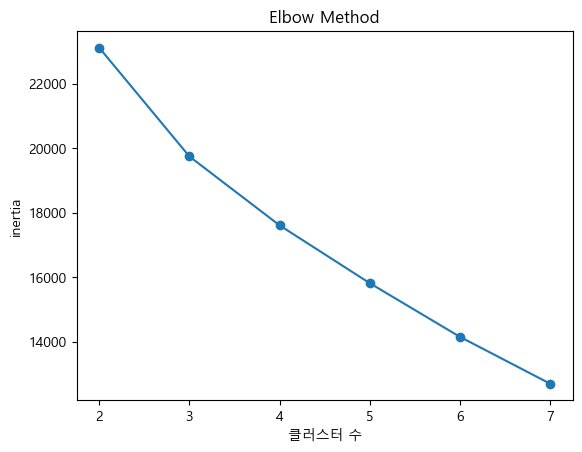

In [53]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_cols = ['이전_효율성','이전_양봉비율','이전_평균마감위치','이전_거래량기울기',
                 '이후_최대되돌림','이후_양봉비율','이후_첫음봉까지봉수','이후_거래량기울기']

X_cluster = traj_df[cluster_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 먼저 몇 개 클러스터가 적절한지 elbow method로 확인
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.plot(range(2,8), inertias, marker='o')
plt.xlabel('클러스터 수')
plt.ylabel('inertia')
plt.title('Elbow Method')
plt.show()

In [54]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
traj_df['클러스터'] = km_final.fit_predict(X_scaled)

print(traj_df['클러스터'].value_counts().sort_index())

클러스터
0     677
1    1098
2    1456
3     624
Name: count, dtype: int64


In [55]:
cluster_summary = traj_df.groupby('클러스터')[cluster_cols + ['이후_최종수익률']].mean()
print(cluster_summary)

        이전_효율성   이전_양봉비율  이전_평균마감위치      이전_거래량기울기   이후_최대되돌림   이후_양봉비율  \
클러스터                                                                      
0     0.105673  0.293069   0.392536 -148151.611226  13.636741  0.290620   
1     0.027554  0.156977   0.348931  -13108.215483   0.983105  0.029189   
2     1.567837  0.810039   0.669034 -112270.526030   6.072723  0.159913   
3     0.858793  0.759624   0.632284 -859155.288462   5.811896  0.602885   

      이후_첫음봉까지봉수      이후_거래량기울기  이후_최종수익률  
클러스터                                       
0       0.155096 -305899.449188 -7.824446  
1       0.094718  -53923.039396  0.168615  
2       0.050824 -360264.173008 -2.797263  
3       1.375000 -715297.681227  0.963205  


In [56]:
cluster_result = traj_df.groupby('클러스터').agg(
    건수=('이후_최종수익률','size'),
    평균수익률=('이후_최종수익률','mean'),
    승률=('이후_최종수익률', lambda x: (x>0).mean()),
    하위10퍼센트=('이후_최종수익률', lambda x: x.quantile(0.1)),
)
print(cluster_result)

        건수     평균수익률        승률    하위10퍼센트
클러스터                                     
0      677 -7.824446  0.181684 -18.942339
1     1098  0.168615  0.111111   0.000000
2     1456 -2.797263  0.157967  -9.236847
3      624  0.963205  0.743590  -3.806717


In [57]:
print(traj_df.groupby('클러스터')['이전_거래량기울기'].describe())

       count           mean           std         min        25%  50%  \
클러스터                                                                    
0      677.0 -148151.611226  8.701072e+05  -9677069.0       0.00  0.0   
1     1098.0  -13108.215483  2.721697e+05  -5966238.4       0.00  0.0   
2     1456.0 -112270.526030  2.330117e+06 -18048460.0  -78203.50  0.0   
3      624.0 -859155.288462  3.990162e+06 -55648496.0 -311768.95  0.0   

            75%         max  
클러스터                         
0         0.000   1930076.3  
1         0.000   2579992.0  
2     16099.750  41475157.0  
3       162.025   8597988.0  


In [58]:
traj_df['날짜dt'] = pd.to_datetime(traj_df['날짜'])
split_date = traj_df['날짜dt'].median()

train = traj_df[traj_df['날짜dt'] < split_date].copy()
test = traj_df[traj_df['날짜dt'] >= split_date].copy()

# 학습 데이터로만 스케일러+클러스터 학습
X_train_c = train[cluster_cols].fillna(0)
scaler_wf = StandardScaler()
X_train_scaled = scaler_wf.fit_transform(X_train_c)

km_wf = KMeans(n_clusters=4, random_state=42, n_init=10)
train['클러스터_wf'] = km_wf.fit_predict(X_train_scaled)

# 학습된 스케일러+클러스터 모델을 검증 데이터에 적용
X_test_c = test[cluster_cols].fillna(0)
X_test_scaled = scaler_wf.transform(X_test_c)
test['클러스터_wf'] = km_wf.predict(X_test_scaled)

print("=== 학습기간 클러스터별 결과 ===")
print(train.groupby('클러스터_wf')['이후_최종수익률'].agg(['count','mean']))
print("\n=== 검증기간 클러스터별 결과 ===")
print(test.groupby('클러스터_wf')['이후_최종수익률'].agg(['count','mean']))

=== 학습기간 클러스터별 결과 ===
         count      mean
클러스터_wf                 
0          325  0.981467
1          339 -6.370454
2          478  0.261970
3          771 -2.932967

=== 검증기간 클러스터별 결과 ===
         count      mean
클러스터_wf                 
0          297  1.054740
1          373 -8.330517
2          603  0.085091
3          669 -2.786799


In [59]:
# 학습기간 기준 클러스터0의 특징 다시 확인
print(train[train['클러스터_wf']==0][cluster_cols].mean())
print(f"\n클러스터0 승률: {(train[train['클러스터_wf']==0]['이후_최종수익률']>0).mean()*100:.1f}%")

# 검증기간에서도 동일 클러스터의 특징이 비슷한지 (분포가 안정적인지)
print(train[train['클러스터_wf']==0]['이후_최종수익률'].describe())
print(test[test['클러스터_wf']==0]['이후_최종수익률'].describe())

이전_효율성             0.944215
이전_양봉비율            0.759253
이전_평균마감위치          0.636743
이전_거래량기울기    -815849.110462
이후_최대되돌림           5.692117
이후_양봉비율            0.616718
이후_첫음봉까지봉수         1.378462
이후_거래량기울기    -787204.671560
dtype: float64

클러스터0 승률: 74.5%
count    325.000000
mean       0.981467
std        3.720487
min      -15.441176
25%        0.000000
50%        1.908802
75%        3.556188
max        5.598958
Name: 이후_최종수익률, dtype: float64
count    297.000000
mean       1.054740
std        3.833584
min      -19.161677
25%        0.131234
50%        1.747573
75%        3.612717
max        5.584129
Name: 이후_최종수익률, dtype: float64


In [60]:
cluster0_train = train[train['클러스터_wf']==0]
others_train = train[train['클러스터_wf']!=0]

for col in cluster_cols:
    print(f"\n=== {col} ===")
    print(f"클러스터0(좋음): 25%={cluster0_train[col].quantile(0.25):.3f}, 중앙값={cluster0_train[col].median():.3f}, 75%={cluster0_train[col].quantile(0.75):.3f}")
    print(f"나머지: 25%={others_train[col].quantile(0.25):.3f}, 중앙값={others_train[col].median():.3f}, 75%={others_train[col].quantile(0.75):.3f}")


=== 이전_효율성 ===
클러스터0(좋음): 25%=0.538, 중앙값=0.725, 75%=1.018
나머지: 25%=0.000, 중앙값=0.340, 75%=1.024

=== 이전_양봉비율 ===
클러스터0(좋음): 25%=0.550, 중앙값=0.800, 75%=1.000
나머지: 25%=0.600, 중앙값=0.800, 75%=1.000

=== 이전_평균마감위치 ===
클러스터0(좋음): 25%=0.525, 중앙값=0.636, 75%=0.738
나머지: 25%=0.530, 중앙값=0.651, 75%=0.783

=== 이전_거래량기울기 ===
클러스터0(좋음): 25%=-443498.000, 중앙값=0.000, 75%=22913.000
나머지: 25%=0.000, 중앙값=0.000, 75%=0.000

=== 이후_최대되돌림 ===
클러스터0(좋음): 25%=3.748, 중앙값=5.000, 75%=6.759
나머지: 25%=0.000, 중앙값=5.165, 75%=9.547

=== 이후_양봉비율 ===
클러스터0(좋음): 25%=0.500, 중앙값=0.500, 75%=0.750
나머지: 25%=0.000, 중앙값=0.000, 75%=0.333

=== 이후_첫음봉까지봉수 ===
클러스터0(좋음): 25%=1.000, 중앙값=1.000, 75%=2.000
나머지: 25%=0.000, 중앙값=0.000, 75%=0.000

=== 이후_거래량기울기 ===
클러스터0(좋음): 25%=-805057.000, 중앙값=-216920.500, 75%=-2031.900
나머지: 25%=-267119.646, 중앙값=-28580.707, 75%=-609.654


In [61]:
from sklearn.tree import DecisionTreeClassifier, export_text

X_train_rule = train[cluster_cols].fillna(0)
y_train_rule = (train['클러스터_wf'] == 0).astype(int)

rule_tree = DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42)
rule_tree.fit(X_train_rule, y_train_rule)
print(export_text(rule_tree, feature_names=cluster_cols))

|--- 이후_첫음봉까지봉수 <= 0.50
|   |--- 이전_거래량기울기 <= -2869007.75
|   |   |--- class: 0
|   |--- 이전_거래량기울기 >  -2869007.75
|   |   |--- class: 0
|--- 이후_첫음봉까지봉수 >  0.50
|   |--- 이후_양봉비율 <= 0.23
|   |   |--- class: 0
|   |--- 이후_양봉비율 >  0.23
|   |   |--- class: 1



In [62]:
X_test_rule = test[cluster_cols].fillna(0)
test['규칙예측'] = rule_tree.predict(X_test_rule)

print(test.groupby('규칙예측')['이후_최종수익률'].agg(['count','mean']))
print(f"\n규칙 예측 승률: {(test[test['규칙예측']==1]['이후_최종수익률']>0).mean()*100:.1f}%")

      count      mean
규칙예측                 
0      1595 -2.953144
1       347  0.297351

규칙 예측 승률: 70.3%


In [63]:
pre_only_cols = ['이전_효율성', '이전_양봉비율', '이전_평균마감위치', '이전_거래량기울기']

X_train_rule2 = train[pre_only_cols].fillna(0)
y_train_rule2 = (train['클러스터_wf'] == 0).astype(int)

rule_tree2 = DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42)
rule_tree2.fit(X_train_rule2, y_train_rule2)
print(export_text(rule_tree2, feature_names=pre_only_cols))

|--- 이전_평균마감위치 <= 0.23
|   |--- class: 0
|--- 이전_평균마감위치 >  0.23
|   |--- 이전_효율성 <= 0.95
|   |   |--- class: 0
|   |--- 이전_효율성 >  0.95
|   |   |--- class: 0



In [64]:
X_test_rule2 = test[pre_only_cols].fillna(0)
test['규칙예측2'] = rule_tree2.predict(X_test_rule2)
print(test.groupby('규칙예측2')['이후_최종수익률'].agg(['count','mean']))

       count      mean
규칙예측2                 
0       1942 -2.372339


In [65]:
# "이벤트 이후 첫봉이 양봉이면 계속 보유, 음봉이면 즉시 손절"이라는 규칙을 시뮬레이션
def first_bar_rule(row_traj):
    post = row_traj['post']
    if len(post) == 0:
        return None
    first_bar_bullish = post.iloc[0]['cur_prc'] > post.iloc[0]['open_pric']
    if not first_bar_bullish:
        # 즉시 손절 - 그 첫봉 종가에 청산했다고 가정
        event_price = row_traj['event']['cur_prc']
        exit_price = post.iloc[0]['cur_prc']
        return (exit_price - event_price) / event_price * 100
    else:
        # 보유 지속 - 최종 결과 그대로
        event_price = row_traj['event']['cur_prc']
        final_price = post.iloc[-1]['cur_prc']
        return (final_price - event_price) / event_price * 100

In [66]:
def first_bar_rule(row_traj):
    post = row_traj['post']
    if len(post) == 0:
        return None
    first_bar_bullish = post.iloc[0]['cur_prc'] > post.iloc[0]['open_pric']
    event_price = row_traj['event']['cur_prc']
    if not first_bar_bullish:
        exit_price = post.iloc[0]['cur_prc']
        return (exit_price - event_price) / event_price * 100
    else:
        final_price = post.iloc[-1]['cur_prc']
        return (final_price - event_price) / event_price * 100

# 실제로 trajectories 전체에 적용
results_v2 = []
for t in trajectories:
    if len(t['post']) == 0:
        continue
    r = first_bar_rule(t)
    if r is None:
        continue
    results_v2.append({'종목코드': t['종목코드'], '날짜': t['날짜'], '규칙적용수익률': r})

rule_df = pd.DataFrame(results_v2)
print(rule_df.shape)
print(rule_df['규칙적용수익률'].describe())
print(f"평균: {rule_df['규칙적용수익률'].mean():.3f}%")
print(f"승률: {(rule_df['규칙적용수익률']>0).mean()*100:.1f}%")

(3855, 3)
count    3855.000000
mean       -1.409681
std         3.852541
min       -44.675741
25%        -2.644231
50%         0.000000
75%         0.000000
max         5.641422
Name: 규칙적용수익률, dtype: float64
평균: -1.410%
승률: 18.0%


In [67]:
def rolling_stop_rule(row_traj):
    post = row_traj['post']
    if len(post) == 0:
        return None
    event_price = row_traj['event']['cur_prc']

    for i in range(len(post)):
        bar = post.iloc[i]
        is_bullish = bar['cur_prc'] > bar['open_pric']
        if not is_bullish:
            # 이 봉에서 음봉 나오면 즉시 손절
            exit_price = bar['cur_prc']
            return (exit_price - event_price) / event_price * 100

    # 끝까지 전부 양봉이었으면 마지막 가격으로 마감
    final_price = post.iloc[-1]['cur_prc']
    return (final_price - event_price) / event_price * 100

results_v3 = []
for t in trajectories:
    if len(t['post']) == 0:
        continue
    r = rolling_stop_rule(t)
    if r is None:
        continue
    results_v3.append({'종목코드': t['종목코드'], '날짜': t['날짜'], '롤링손절수익률': r})

rolling_df = pd.DataFrame(results_v3)
print(rolling_df.shape)
print(rolling_df['롤링손절수익률'].describe())
print(f"평균: {rolling_df['롤링손절수익률'].mean():.3f}%")
print(f"승률: {(rolling_df['롤링손절수익률']>0).mean()*100:.1f}%")

(3855, 3)
count    3855.000000
mean       -1.234866
std         3.543614
min       -34.776632
25%        -2.252570
50%         0.000000
75%         0.000000
max         5.641422
Name: 롤링손절수익률, dtype: float64
평균: -1.235%
승률: 19.1%


In [68]:
wins = rolling_df[rolling_df['롤링손절수익률']>0]['롤링손절수익률']
losses = rolling_df[rolling_df['롤링손절수익률']<=0]['롤링손절수익률']
print(f"평균 승리: {wins.mean():.2f}%, 평균 손실: {losses.mean():.2f}%")
print(f"손익비: {abs(wins.mean()/losses.mean()):.2f}")
print(f"기대값 재확인: {(len(wins)/len(rolling_df))*wins.mean() + (len(losses)/len(rolling_df))*losses.mean():.3f}%")

평균 승리: 2.38%, 평균 손실: -2.09%
손익비: 1.14
기대값 재확인: -1.235%


In [69]:
def hourly_retention_matrix(thresholds, reach_hours):
    results = []
    for TH in thresholds:
        hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
        fh = hit.groupby(['종목코드','날짜']).first().reset_index()

        for RH in reach_hours:
            # 해당 시각에 "최초로" 도달한 케이스만 (event_time의 시(hour)가 RH인 것)
            subset = fh[fh['cntr_tm'].dt.hour == RH].copy()

            returns = []
            for _, row in subset.iterrows():
                day_data = day_groups.get((row['종목코드'], row['날짜']))
                if day_data is None:
                    continue
                bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
                if len(bar_1500) == 0:
                    continue
                close_1500 = bar_1500.iloc[0]['cur_prc']
                daily_return = (close_1500 - row['전일종가']) / row['전일종가'] * 100
                returns.append(daily_return)

            if len(returns) == 0:
                continue

            returns = pd.Series(returns)
            results.append({
                '임계값': TH, '도달시각': RH, '건수': len(returns),
                '유지율(임계값이상)': (returns >= TH).mean() * 100,
                '평균종가등락률': returns.mean(),
                '평균반납폭': (TH - returns).mean(),
            })
    return pd.DataFrame(results)

matrix_df = hourly_retention_matrix([18,20,23,25,27], [9,10,11,12,13,14])
print(matrix_df)

# 피벗테이블로 보기 좋게
pivot = matrix_df.pivot(index='도달시각', columns='임계값', values='유지율(임계값이상)')
print(pivot)

    임계값  도달시각    건수  유지율(임계값이상)    평균종가등락률     평균반납폭
0    18     9  2648   69.939577  22.451525 -4.451525
1    18    10  1009   60.356789  20.246222 -2.246222
2    18    11   695   54.676259  19.685888 -1.685888
3    18    12   606   48.679868  18.127357 -0.127357
4    18    13   665   52.631579  19.198755 -1.198755
5    18    14   549   66.302368  20.370591 -2.370591
6    20     9  2184   71.703297  23.815872 -3.815872
7    20    10   833   60.504202  21.757972 -1.757972
8    20    11   539   56.586271  21.418110 -1.418110
9    20    12   509   51.080550  20.042482 -0.042482
10   20    13   542   50.369004  20.365247 -0.365247
11   20    14   471   62.420382  21.774524 -1.774524
12   23     9  1668   76.678657  25.529839 -2.529839
13   23    10   615   64.065041  24.102021 -1.102021
14   23    11   378   65.079365  24.408998 -1.408998
15   23    12   346   60.115607  23.625539 -0.625539
16   23    13   410   58.780488  23.516051 -0.516051
17   23    14   433   56.120092  23.311967 -0.

In [70]:
# 09시 도달 + 27%+ 조합의 실제 진입수익률 확인
best_combo = matrix_df[(matrix_df['도달시각']==9) & (matrix_df['임계값']==27)]
print(best_combo)

# 이 조합만 따로 뽑아서 실제 진입 대비 손익 계산 필요

    임계값  도달시각    건수  유지율(임계값이상)    평균종가등락률     평균반납폭
24   27     9  1270   83.700787  26.931109  0.068891


In [72]:
TH = 18
hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
fh = hit.groupby(['종목코드','날짜']).first().reset_index()

sample = fh[fh['cntr_tm'].dt.hour == 9].head(20).copy()
sample['시가_등락률'] = (sample['open_pric'] - sample['전일종가']) / sample['전일종가'] * 100
print(sample[['종목코드','날짜','open_pric','cur_prc','전일종가','시가_등락률','누적등락률']])

    종목코드          날짜  open_pric   cur_prc      전일종가     시가_등락률      누적등락률
1     40  2025-07-30      653.0     653.0     503.0  29.821074  29.821074
2     50  2025-12-12     9830.0   11010.0    8470.0  16.056671  29.988194
3     50  2025-12-15    12840.0   13850.0   11010.0  16.621253  25.794732
4     50  2026-02-03     9620.0   11230.0    9380.0   2.558635  19.722814
11   210  2026-03-20    59000.0   63600.0   51300.0  15.009747  23.976608
17   250  2025-07-23   166100.0  213500.0  164600.0   0.911300  29.708384
20   250  2026-03-05   730000.0  765000.0  645000.0  13.178295  18.604651
23   370  2026-02-20     7580.0    8820.0    7430.0   2.018843  18.707941
24   390  2025-12-18     6390.0    7610.0    6100.0   4.754098  24.754098
25   390  2025-12-19     9500.0    9520.0    7930.0  19.798235  20.050441
27   390  2026-02-10    10310.0   12350.0    9500.0   8.526316  30.000000
28   390  2026-03-06     8000.0   10120.0    7790.0   2.695764  29.910141
34   400  2026-06-29     2100.0    224

In [73]:
TH = 18
hit_9 = fh[fh['cntr_tm'].dt.hour == 9].copy()
hit_9['시가등락률'] = (hit_9['open_pric'] - hit_9['전일종가']) / hit_9['전일종가'] * 100

# 시가부터 이미 임계값 근접(예: 임계값의 80% 이상)했는지로 구분
hit_9['유형'] = np.where(hit_9['시가등락률'] >= TH*0.8, '시가갭형', '개장직후급등형')
print(hit_9['유형'].value_counts())

# 유형별로 15시 종가까지의 유지율 비교
results = []
for _, row in hit_9.iterrows():
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    if day_data is None:
        continue
    bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
    if len(bar_1500) == 0:
        continue
    close_1500 = bar_1500.iloc[0]['cur_prc']
    daily_return = (close_1500 - row['전일종가']) / row['전일종가'] * 100
    results.append({'유형': row['유형'], '종가등락률': daily_return})

result_df = pd.DataFrame(results)
print(result_df.groupby('유형')['종가등락률'].agg(['count','mean', lambda x: (x>=TH).mean()*100]))

유형
개장직후급등형    1952
시가갭형        699
Name: count, dtype: int64
         count       mean  <lambda_0>
유형                                   
개장직후급등형   1952  21.598654   66.137295
시가갭형       696  24.843487   80.603448


In [75]:
def compare_gap_types_fixed(TH, gap_ratio=0.8):
    hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
    fh_local = hit.groupby(['종목코드','날짜']).first().reset_index()
    hit_9 = fh_local[fh_local['cntr_tm'].dt.hour == 9].copy()
    hit_9['시가등락률'] = (hit_9['open_pric'] - hit_9['전일종가']) / hit_9['전일종가'] * 100
    hit_9['유형'] = np.where(hit_9['시가등락률'] >= TH*gap_ratio, '시가갭형', '개장직후급등형')

    results = []
    for _, row in hit_9.iterrows():
        day_data = day_groups.get((row['종목코드'], row['날짜']))
        if day_data is None:
            continue
        bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
        if len(bar_1500) == 0:
            continue
        close_1500 = bar_1500.iloc[0]['cur_prc']

        # 실제 진입 가능 가격 = 이벤트가 감지된 그 시점의 가격 (09시봉 종가 = cur_prc)
        actual_entry_price = row['cur_prc']
        entry_return = (close_1500 - actual_entry_price) / actual_entry_price * 100

        results.append({'유형': row['유형'], '진입수익률': entry_return})

    rdf = pd.DataFrame(results)
    summary = rdf.groupby('유형').agg(
        건수=('진입수익률','size'),
        평균진입수익률=('진입수익률','mean'),
        승률=('진입수익률', lambda x: (x>0).mean()*100),
    )
    summary['임계값'] = TH
    return summary

all_results_fixed = pd.concat([compare_gap_types_fixed(th) for th in [18,20,23,25,27]])
print(all_results_fixed)

           건수   평균진입수익률         승률  임계값
유형                                     
개장직후급등형  1952 -2.540344  26.793033   18
시가갭형      696 -2.044387  15.086207   18
개장직후급등형  1622 -2.555516  24.229346   20
시가갭형      562 -1.978108  11.921708   20
개장직후급등형  1229 -2.560640  19.446705   23
시가갭형      439 -1.727184   7.289294   23
개장직후급등형  1060 -2.390749  15.471698   25
시가갭형      380 -1.663073   4.473684   25
개장직후급등형   934 -2.385389   9.421842   27
시가갭형      336 -1.418661   1.488095   27


In [76]:
import os
print(os.path.exists('merged_ohlcv.csv'))


True


In [ ]:
import pandas as pd
daily_df = pd.read_csv('merged_ohlcv.csv')
daily_df['날짜'] = pd.to_datetime(daily_df['날짜'])
print(daily_df.shape)